<a href="https://colab.research.google.com/github/Imran1hp/Deep-Learning-/blob/main/PyTorch_Computer_vision.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import torch
from torch import nn

import torchvision
from torchvision import datasets
from torchvision import transforms
from torchvision.transforms import ToTensor
import  matplotlib.pyplot as plt




## Download the datastes from torchvision

In [ ]:
from torchvision import datasets

train_data = datasets.FashionMNIST(
    root = 'data', # where to download the data to
    train = True, # do we want the train data set
    download = True,# do we want to downlaod it
    transform = torchvision.transforms.ToTensor(), # do we want to transform the data into tensor
    target_transform = None # to we wnat to change the target labels

)

test_data = datasets.FashionMNIST(
    root ='data',
    train = False,
    download = True,
    transform = ToTensor(),
    target_transform = None

)

In [ ]:
len(train_data),len(test_data)

(60000, 10000)

In [ ]:
image,labels = train_data[0]

In [ ]:
image ,labels

(tensor([[[0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0039, 0.0000, 0.0000, 0.0510,
           0.2863, 0.0000, 0.0000, 0.0039, 

In [ ]:
class_name = train_data.classes

In [ ]:
class_name

['T-shirt/top',
 'Trouser',
 'Pullover',
 'Dress',
 'Coat',
 'Sandal',
 'Shirt',
 'Sneaker',
 'Bag',
 'Ankle boot']

In [ ]:
class_to_idx = train_data.class_to_idx
class_to_idx

{'T-shirt/top': 0,
 'Trouser': 1,
 'Pullover': 2,
 'Dress': 3,
 'Coat': 4,
 'Sandal': 5,
 'Shirt': 6,
 'Sneaker': 7,
 'Bag': 8,
 'Ankle boot': 9}

In [ ]:
train_data.targets

tensor([9, 0, 0,  ..., 3, 0, 5])

In [ ]:
image.shape ,labels

(torch.Size([1, 28, 28]), 9)

shape of the image torch.Size([1, 28, 28])


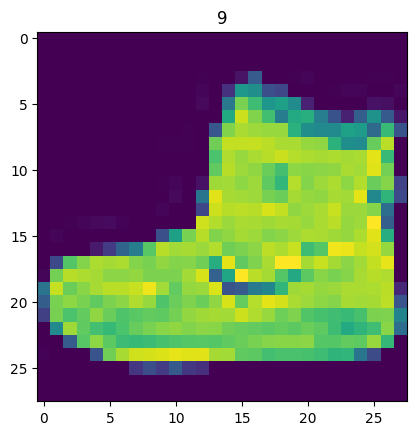

In [ ]:
import matplotlib.pyplot as plt

image , labels = train_data[0]
print(f"shape of the image {image.shape}")
plt.title(labels)
plt.imshow(image.squeeze())

In [ ]:
image.shape

torch.Size([1, 28, 28])

In [ ]:
image.squeeze().shape

torch.Size([28, 28])

(-0.5, 27.5, 27.5, -0.5)

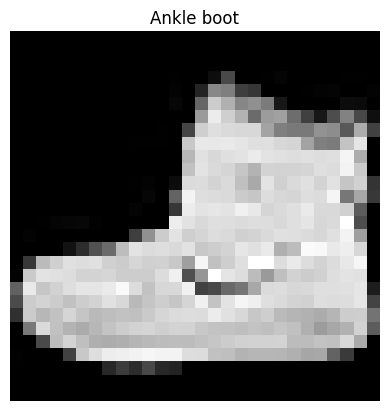

In [ ]:
plt.imshow(image.squeeze() , cmap = 'gray')
plt.title(class_name[labels])
plt.axis(False)

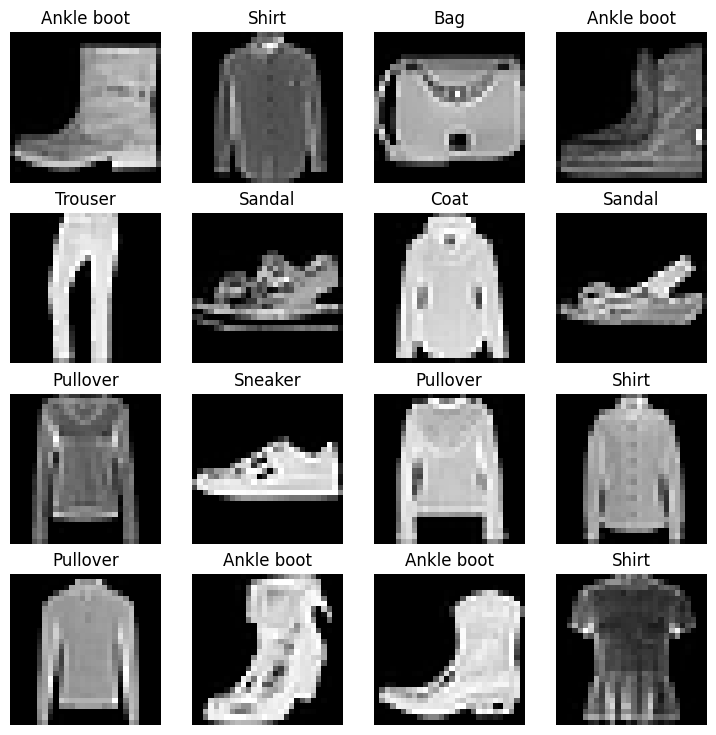

In [ ]:
torch.manual_seed(42)
fig = plt.figure(figsize=(9,9))
row , col = 4,4

for i in range(1, row * col + 1 ):
  random_idx = torch.randint( 0 , len(train_data), size = [1]).item()
  image , labels = train_data[random_idx]
  fig.add_subplot(row , col ,i)
  plt.imshow(image.squeeze(),cmap='gray')
  plt.title(class_name[labels])
  plt.axis(False)


## Turn our data in to mini batches so our machine ram or memory don't consume by it fully default batch size is 32  

using DataLoader function

In [ ]:
from torch.utils.data import DataLoader

BATCH_SIZE = 32

train_data_loader = DataLoader(train_data , batch_size = BATCH_SIZE , shuffle = True)

test_data_loader = DataLoader(test_data , batch_size = BATCH_SIZE , shuffle = False)

train_data_loader has 1875  batch inside it and each batch has 32 images  

In [ ]:
print(f"Length of the train data loader: {len(train_data_loader)} of each batch size {BATCH_SIZE}")
print(f"Length of the test data loader: {len(test_data_loader)} of each batch size {BATCH_SIZE}")

Length of the train data loader: 1875 of each batch size 32
Length of the test data loader: 313 of each batch size 32


In [ ]:
60000/32

1875.0

In [ ]:
10000/32

312.5

In [ ]:
train_feature_batch , train_label_batch = next(iter(train_data_loader))
train_feature_batch.shape , train_label_batch.shape

(torch.Size([32, 1, 28, 28]), torch.Size([32]))

 32 is batch size 1 is color channel 28 and 28 hight and width

 ## train_feature_batch is 1 batch which is we iterating one by one by next(iter()) function  from train_data_loader

In [ ]:
len(train_feature_batch)

32

Image size torch.Size([1, 28, 28])
Lable: 6 lable shape torch.Size([])


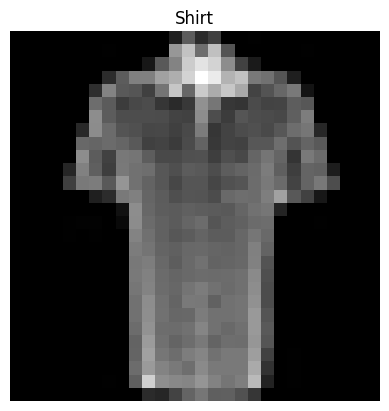

In [ ]:
torch.manual_seed(42)

random_idx = torch.randint( 0 , len(train_feature_batch) , size=[1]).item()
img , labels = train_feature_batch[random_idx] , train_label_batch[random_idx]

plt.imshow(img.squeeze() , cmap = 'gray')
plt.title ( class_name[labels])
plt.axis(False)
print(f"Image size {img.shape}")
print(f"Lable: {labels} lable shape {labels.shape}")

 ## Flatten the input by nn.flatten module

In [ ]:
from torch import nn

flatten_output = nn.Flatten()
x = train_feature_batch[0]
output = flatten_output(x)
print(f" Original shape of the image: {x.shape}")
print(f" Flatten shape of the image: {output.shape}")

 Original shape of the image: torch.Size([1, 28, 28])
 Flatten shape of the image: torch.Size([1, 784])


In [ ]:
device = ""
if torch.cuda.is_available:
  device = "cuda"
else:
  device = "cpu"

In [ ]:
class FashionMNISTModelv0(nn.Module):
  def __init__(self , input_shape =int, hidden_unit = int , output_shape = int):
    super().__init__()
    self.layer_stack = nn.Sequential(
      nn.Flatten(),
      nn.Linear(in_features = input_shape , out_features = hidden_unit),
      nn.Linear(in_features = hidden_unit , out_features = output_shape)
    )
  def forward(self , x):
    return self.layer_stack(x)

In [ ]:
class_name

['T-shirt/top',
 'Trouser',
 'Pullover',
 'Dress',
 'Coat',
 'Sandal',
 'Shirt',
 'Sneaker',
 'Bag',
 'Ankle boot']

In [ ]:
torch.manual_seed(42)
torch.cuda.manual_seed(42)

# Correctly determine the device locally
if torch.cuda.is_available():
 device = "cuda"
else:
 device = "cpu"

model_0 = FashionMNISTModelv0(input_shape = 28*28 , hidden_unit = 10 , output_shape = len(class_name)).to(device)

In [ ]:
model_0

FashionMNISTModelv0(
  (layer_stack): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=784, out_features=10, bias=True)
    (2): Linear(in_features=10, out_features=10, bias=True)
  )
)

In [ ]:
dummy_x = torch.rand([1,1 ,28,28]).to(device)
model_0(dummy_x).shape

torch.Size([1, 10])

In [ ]:
def accuarcy_fn ( y_true , y_preds ):
  correct = torch.eq(y_true , y_preds).sum().item()
  acc = (correct/len(y_preds))*100
  return acc

In [ ]:
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(params = model_0.parameters() , lr =0.1)

In [ ]:
from timeit import default_timer as timer

def print_train_time (start: float , end: float , device: torch.device = None):
  total_time = end - start
  print(f"Train time on {device} is {total_time:.3f}s")
  return total_time

In [ ]:
start_time = timer()
cal = 10**2 * 8**3

end_time = timer()
print_train_time(start=start_time , end=end_time , device = "cpu")

Train time on cpu is 0.000s


0.000205526999934591

## Train a model in batch of data

In [ ]:
len(train_data_loader)

1875

In [ ]:
from tqdm.auto import tqdm

torch.manual_seed(42)
torch.cuda.manual_seed(42)
starting_time = timer()

epochs =3

for epoch in tqdm(range(epochs)):
      print(f"Epochs:{epoch}\n-----")
      train_loss = 0

      for batch ,(X,y ) in enumerate(train_data_loader):
        X, y = X.to(device), y.to(device) # Move data to target device

        model_0.train()

        y_preds = model_0(X)

        loss =loss_fn(y_preds , y)
        train_loss +=loss

        optimizer.zero_grad()

        loss.backward()

        optimizer.step()

        if batch %400 == 0:
         print(f"Look at {batch*len(X)} / {len(train_data_loader.dataset)} sample")

      train_loss /=len(train_data_loader) # Average the loss over all batches

      test_loss , test_acc = 0 ,0
      model_0.eval()

      with torch.inference_mode():

        for test_X , test_y in test_data_loader:
          test_X, test_y = test_X.to(device), test_y.to(device) # Move data to target device
          test_pred = model_0(test_X)

          test_loss += loss_fn(test_pred , test_y) # Sum test loss

          test_acc += accuarcy_fn(y_true = test_y , y_preds = test_pred.argmax(dim =1)) # Sum test accuracy

        test_loss /=len(test_data_loader) # Average test loss
        test_acc /= len(test_data_loader) # Average test accuracy
      print(f"Train_loss: {train_loss:.4f} |  Test loss: {test_loss:.4f} | Test_ACC: {test_acc:.4f}")


end_time = timer() # Fix: Assign timer() to end_time

print_train_time(start_time , end_time , device =str(next(model_0.parameters()).device)) # Fix: Pass correct device

  0%|          | 0/3 [00:00<?, ?it/s]

Epochs:0
-----
Look at 0 / 60000 sample
Look at 12800 / 60000 sample
Look at 25600 / 60000 sample
Look at 38400 / 60000 sample
Look at 51200 / 60000 sample
Train_loss: 0.5904 |  Test loss: 0.5095 | Test_ACC: 82.0387
Epochs:1
-----
Look at 0 / 60000 sample
Look at 12800 / 60000 sample
Look at 25600 / 60000 sample
Look at 38400 / 60000 sample
Look at 51200 / 60000 sample
Train_loss: 0.4763 |  Test loss: 0.4799 | Test_ACC: 83.1969
Epochs:2
-----
Look at 0 / 60000 sample
Look at 12800 / 60000 sample
Look at 25600 / 60000 sample
Look at 38400 / 60000 sample
Look at 51200 / 60000 sample
Train_loss: 0.4550 |  Test loss: 0.4766 | Test_ACC: 83.4265
Train time on cuda:0 is 28.289s


28.28915653399997

In [ ]:
torch.manual_seed(42)
def model_eval(model: torch.nn.Module , data_loader: torch.utils.data.DataLoader , loss_fn : torch.nn.Module , accuarcy_fn):
  loss , acc = 0, 0
  with torch.inference_mode():
    for X, y in data_loader:
      X , y = X.to(device) ,y.to(device)

      y_preds = model(X)


      loss+=loss_fn(y_preds ,y )

      acc += accuarcy_fn(y_true = y , y_preds = y_preds.argmax(dim=1))


    loss/=len(data_loader)
    acc/=len(data_loader)

  return {"Model_name": model.__class__.__name__,
          "Model_loss": loss.item(),
          "Model_Acc": acc}





In [ ]:
model_0_result = model_eval( model = model_0 , data_loader = test_data_loader ,
                            loss_fn = loss_fn , accuarcy_fn = accuarcy_fn)


In [ ]:

model_0_result

{'Model_name': 'FashionMNISTModelv0',
 'Model_loss': 0.4766389727592468,
 'Model_Acc': 83.42651757188499}

## Create a non liner Model with ReLU activation functin

In [ ]:
class FashionMNISTModelV1(nn.Module):
  def __init__(self , input_features: int , hidden_units:int , output_features: int):
    super().__init__()
    self.layer_stack = nn.Sequential(
        nn.Flatten(),
        nn.Linear(in_features = input_features , out_features = hidden_units),
        nn.ReLU(),
        nn.Linear(in_features = hidden_units , out_features = output_features ),
        nn.ReLU()
    )
  def forward(self , x:torch.tensor):
    return self.layer_stack(x)

In [ ]:
torch.manual_seed(42)
model_1 = FashionMNISTModelV1(input_features = 28* 28 , hidden_units = 10 , output_features = len(class_name)).to(device)

In [ ]:
next(model_1.parameters()).device

device(type='cuda', index=0)

In [ ]:
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(model_1.parameters(), lr =0.1)

In [ ]:
def train_step(model: torch.nn.Module ,dataloader:torch.utils.data.DataLoader , loss_fn: torch.nn.Module,
               optimizer: torch.optim.Optimizer  ,accuarcy_fn , device:torch.device = device ):

  train_loss , train_acc = 0 , 0
  model.train()

  for batch ,(X,y) in enumerate(dataloader):

    X ,y = X.to(device ) , y.to(device)

    y_preds = model(X)

    loss = loss_fn(y_preds , y)
    train_loss += loss
    train_acc += accuarcy_fn( y_true = y ,y_preds = y_preds.argmax(dim=1) )

    optimizer.zero_grad()

    loss.backward()
    optimizer.step()

  train_loss/=len(dataloader)
  train_acc /=len(dataloader)

  print(f"Train Loss: { train_loss:.5f}  | Train_acc: { train_acc:.2f}")


In [ ]:
def test_step (model: torch.nn.Module , dataloader: torch.utils.data.DataLoader ,
               loss_fn: torch.nn.Module ,
               accuarcy_fn , device: torch.device = device):
  model.eval()
  with torch.inference_mode():
    test_loss , test_acc  = 0,0
    for  X, y in dataloader :
      X ,y = X.to(device) ,y.to(device)

      y_preds = model(X)

      loss = loss_fn (y_preds  , y)
      test_loss += loss

      acc = accuarcy_fn(y_true = y , y_preds = y_preds.argmax(dim = 1))
      test_acc += acc

    test_loss /= len(dataloader)
    test_acc /= len(dataloader)
    print(f" Test loss: {test_loss:.5f}  |  Test Acc: {test_acc:.2f}")






In [ ]:
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(params = model_1.parameters() ,lr = 0.1)

In [ ]:

torch.manual_seed(42)
torch.cuda.manual_seed(42)
start_timer = timer()
epochs = 4
for epoch in tqdm(range(epochs)):
  print(f"Epoch : {epoch}\n------------")
  train_step(model=model_1 , dataloader = train_data_loader, loss_fn = loss_fn , accuarcy_fn=accuarcy_fn , optimizer = optimizer )
  test_step( model_1 , dataloader = test_data_loader , loss_fn =nn.CrossEntropyLoss(), accuarcy_fn = accuarcy_fn)




end_timer = timer()
total_train_time = print_train_time(start = start_timer , end=end_timer , device = device)


  0%|          | 0/4 [00:00<?, ?it/s]

Epoch : 0
------------
Train Loss: 1.09199  | Train_acc: 61.34
 Test loss: 0.95636  |  Test Acc: 65.00
Epoch : 1
------------
Train Loss: 0.78101  | Train_acc: 71.93
 Test loss: 0.72227  |  Test Acc: 73.91
Epoch : 2
------------
Train Loss: 0.67027  | Train_acc: 75.94
 Test loss: 0.68500  |  Test Acc: 75.02
Epoch : 3
------------
Train Loss: 0.64384  | Train_acc: 76.52
 Test loss: 0.65079  |  Test Acc: 76.13
Train time on cuda is 40.357s


In [ ]:
model_0_result

{'Model_name': 'FashionMNISTModelv0',
 'Model_loss': 0.4766389727592468,
 'Model_Acc': 83.42651757188499}

In [ ]:
model_1_result = model_eval(model=model_1 , data_loader = test_data_loader ,
                            loss_fn =loss_fn , accuarcy_fn = accuarcy_fn)
model_1_result

{'Model_name': 'FashionMNISTModelV1',
 'Model_loss': 0.6507946848869324,
 'Model_Acc': 76.12819488817891}

##Model_2 CONVOLUTION NEURAL NETWORK OR CNN

* This Model is using TinyVGG Architechture  



In [ ]:
class FashionMNISTModelV2(nn.Module):
  def __init__(self , input_shape , hidden_units , output_shape):
    super().__init__()
    self.convo_block1 = nn.Sequential(
        nn.Conv2d(in_channels = input_shape , out_channels = hidden_units,
                  kernel_size = 3 ,stride = 1,padding =1),
        nn.ReLU(),
        nn.Conv2d(in_channels= hidden_units , out_channels= hidden_units ,
                  kernel_size = 3 , stride = 1, padding =1 ),
        nn.ReLU(),
        nn.MaxPool2d( kernel_size = 2 )
    )
    self.convo_block2 = nn.Sequential(
        nn.Conv2d( in_channels = hidden_units , out_channels = hidden_units,
                  kernel_size = 3 , stride = 1 , padding =1 ),
        nn.ReLU(),
        nn.Conv2d( in_channels = hidden_units , out_channels = hidden_units,
                  kernel_size = 3 , stride = 1, padding =1 ),
        nn.ReLU(),
        nn.MaxPool2d(kernel_size = 2)
    )
    self.classifer = nn.Sequential(
        nn.Flatten(),
        nn.Linear(in_features = hidden_units * 7 * 7,     # There is a tick to calculate this check line 98
                  out_features = output_shape)
    )

  def forward(self , x):
    x  = self.convo_block1(x)
   #print(f"Output shape of the conv_block_1: {x.shape}")
    x =self.convo_block2(x)
   # print(f"Output shape of the conv_block_2: {x.shape}")
    x = self.classifer(x)
    #print(f"Output shape of the classifier {x.shape}")
    return x


Input shape will be number of color channel in the image

In [ ]:
image.shape[0]

1

In [ ]:
torch.manual_seed(42)
model_2 = FashionMNISTModelV2(input_shape = 1,hidden_units = 10 , output_shape = len(class_name)).to(device)

In [ ]:
next(model_2.parameters()).device

device(type='cuda', index=0)

##What happening in layers


*  Going though nn.conv2d
*   




In [ ]:
torch.manual_seed(42)
image = torch.randn(size=(32 , 3 , 64 ,64))
test_image = image[0]
test_image

tensor([[[ 1.9269,  1.4873,  0.9007,  ...,  1.8446, -1.1845,  1.3835],
         [ 1.4451,  0.8564,  2.2181,  ...,  0.3399,  0.7200,  0.4114],
         [ 1.9312,  1.0119, -1.4364,  ..., -0.5558,  0.7043,  0.7099],
         ...,
         [-0.5610, -0.4830,  0.4770,  ..., -0.2713, -0.9537, -0.6737],
         [ 0.3076, -0.1277,  0.0366,  ..., -2.0060,  0.2824, -0.8111],
         [-1.5486,  0.0485, -0.7712,  ..., -0.1403,  0.9416, -0.0118]],

        [[-0.5197,  1.8524,  1.8365,  ...,  0.8935, -1.5114, -0.8515],
         [ 2.0818,  1.0677, -1.4277,  ...,  1.6612, -2.6223, -0.4319],
         [-0.1010, -0.4388, -1.9775,  ...,  0.2106,  0.2536, -0.7318],
         ...,
         [ 0.2779,  0.7342, -0.3736,  ..., -0.4601,  0.1815,  0.1850],
         [ 0.7205, -0.2833,  0.0937,  ..., -0.1002, -2.3609,  2.2465],
         [-1.3242, -0.1973,  0.2920,  ...,  0.5409,  0.6940,  1.8563]],

        [[-0.7978,  1.0261,  1.1465,  ...,  1.2134,  0.9354, -0.0780],
         [-1.4647, -1.9571,  0.1017,  ..., -1

In [ ]:
test_image.shape

torch.Size([3, 64, 64])

In [ ]:
conv_layer = nn.Conv2d(in_channels = 3 , out_channels = 10 , kernel_size = 3 , padding=0 , stride = 1 )
conv_output = conv_layer(test_image)

In [ ]:
conv_output

tensor([[[-2.8778e-01, -6.0596e-02, -5.6306e-02,  ...,  2.8654e-01,
           6.6224e-01, -2.3216e-01],
         [-9.8911e-01, -4.0099e-01,  4.1832e-01,  ...,  4.7459e-01,
          -1.8552e-01, -5.7622e-01],
         [-4.1340e-02, -2.3277e-01,  3.7418e-01,  ...,  2.8255e-02,
           1.4923e-01,  1.4236e-01],
         ...,
         [-8.0374e-01, -7.6687e-01, -5.9457e-02,  ...,  1.7452e-01,
           4.2594e-01, -4.8341e-01],
         [-1.4512e-01, -1.1566e-01,  6.1783e-01,  ...,  2.4126e-01,
          -3.6626e-01,  3.5645e-01],
         [ 3.6096e-02,  1.5214e-01,  2.3123e-01,  ...,  3.0904e-01,
          -4.9680e-01, -7.2258e-01]],

        [[-1.0853e+00, -1.6079e+00,  1.3346e-01,  ...,  2.1698e-01,
          -1.7643e+00,  2.5263e-01],
         [-8.2507e-01,  6.3866e-01,  1.8845e-01,  ..., -1.0936e-01,
           4.8068e-01,  8.4869e-01],
         [ 6.4927e-01, -4.2061e-03, -4.9991e-01,  ...,  5.8356e-01,
           2.4611e-01,  6.6233e-01],
         ...,
         [ 9.8860e-02,  1

## steping though MaxPool2d

In [ ]:
test_img_through_conv_layer = conv_layer(test_image)
MaxPool_layer  = nn.MaxPool2d(kernel_size =2)
test_img_through_conv_layer_through_maxpool_layer = MaxPool_layer(test_img_through_conv_layer)
print(f"Original test image shape:{test_image.shape}")
print(f"Image shape after through Convolution layer: {test_img_through_conv_layer.shape}")
print(f"Image shape after  through conv_layer them through MaxPool layer: {test_img_through_conv_layer_through_maxpool_layer.shape} ")

Original test image shape:torch.Size([3, 64, 64])
Image shape after through Convolution layer: torch.Size([10, 62, 62])
Image shape after  through conv_layer them through MaxPool layer: torch.Size([10, 31, 31]) 


## how to find out what inputs the classification linear layers infeatures

1.   for that 1st need to run the model with dumy input and see that block_2 output shape
2.  then multiply that shape


In [ ]:
rand_img = torch.randn(size=(1,28,28))
rand_img.shape

torch.Size([1, 28, 28])

In [ ]:
model_2(rand_img.unsqueeze(0).to(device))

tensor([[ 0.0426, -0.0984,  0.0621, -0.0358,  0.0184,  0.0271,  0.0163,  0.0133,
         -0.0038, -0.0115]], device='cuda:0', grad_fn=<AddmmBackward0>)

Here ouput of the block 2 if [10 ,7 , 7] output will nw 10 x 7 x 7 = 490

In [ ]:
# loss and optimizer function

loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD( params = model_2.parameters() , lr = 0.1)

In [ ]:
torch.manual_seed(42)
torch.cuda.manual_seed(42)

start_timer = timer()

epochs = 3
for epoch in tqdm(range(epochs)):
  print(f"Epoch: {epoch}\n--------------")
  train_step(model= model_2 , dataloader = train_data_loader ,
             loss_fn = loss_fn ,optimizer = optimizer ,
             accuarcy_fn = accuarcy_fn , device = device )
  test_step(model= model_2 , dataloader = test_data_loader ,
            loss_fn = loss_fn , accuarcy_fn = accuarcy_fn , device = device)
end_timer = timer()
total_time = print_train_time(start = start_timer , end= end_timer , device = device )

  0%|          | 0/3 [00:00<?, ?it/s]

Epoch: 0
--------------
Train Loss: 0.59286  | Train_acc: 78.41
 Test loss: 0.39493  |  Test Acc: 86.27
Epoch: 1
--------------
Train Loss: 0.35540  | Train_acc: 87.33
 Test loss: 0.34906  |  Test Acc: 87.48
Epoch: 2
--------------
Train Loss: 0.31673  | Train_acc: 88.59
 Test loss: 0.31404  |  Test Acc: 88.77
Train time on cuda is 48.083s


In [ ]:
model_2_result = model_eval( model= model_2 , data_loader = test_data_loader ,
                            loss_fn = loss_fn , accuarcy_fn = accuarcy_fn )
model_2_result

{'Model_name': 'FashionMNISTModelV2',
 'Model_loss': 0.31404298543930054,
 'Model_Acc': 88.7679712460064}

In [ ]:
import pandas as pd
compare_result = pd.DataFrame([model_0_result , model_1_result , model_2_result])
compare_result

,Model_name,Model_loss,Model_Acc
0,FashionMNISTModelv0,0.476639,83.426518
1,FashionMNISTModelV1,0.650795,76.128195
2,FashionMNISTModelV2,0.314043,88.767971


Text(0, 0.5, 'Model')

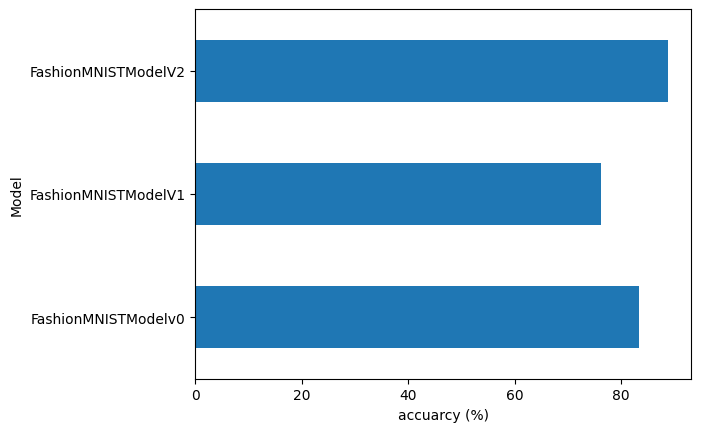

In [ ]:
compare_result.set_index("Model_name")["Model_Acc"].plot(kind='barh')
plt.xlabel("accuarcy (%)")
plt.ylabel("Model")

## Making Prediction on the random data set

In [ ]:
def make_prediction( model: torch.nn.Module , data: list , device:torch.device = device ):
  torch.manual_seed(42)
  model.to(device)
  pred_probs = []
  model.eval()

  with torch.inference_mode():
    for sample in data :
      # unsquzeed the smaple because our model take one batch number one color channel and heigh and width and test_data desn't conatain any batch number
      sample = torch.unsqueeze( sample , dim= 0 ).to(device)
      logit_preds = model(sample)

      pred_prob = torch.softmax(logit_preds.squeeze() , dim = 0)

      pred_probs.append(pred_prob.cpu())

  return torch.stack(pred_probs)

In [ ]:
#test_data[0][:1]

In [ ]:
import random
#random.seed(42)
test_samples =[]
test_labels = []
for sample , label in random.sample (list(test_data) , k =9):
 test_samples.append(sample)
 test_labels.append(label)


print(f"Length of the test sample: {len(test_samples)}")
print(f"shape of the one sample: {test_samples[0].shape}")
print(f"length of the test labels: {len(test_labels)}")



Length of the test sample: 9
shape of the one sample: torch.Size([1, 28, 28])
length of the test labels: 9


Text(0.5, 1.0, 'Dress')

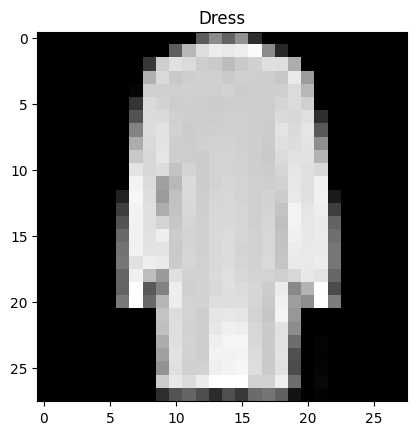

In [ ]:
plt.imshow(test_samples[0].squeeze() , cmap ="gray")
plt.title(class_name[test_labels[0]])

In [ ]:
pred_probs = make_prediction(model =model_2 , data = test_samples , device = device)
pred_probs[0]

tensor([2.6573e-04, 1.2224e-04, 1.2032e-03, 1.9516e-01, 7.9714e-01, 7.1864e-06,
        5.9508e-03, 2.6354e-06, 1.4632e-04, 1.0223e-05])

In [ ]:
pred_classes = pred_probs.argmax(dim=1)
pred_classes

tensor([4, 7, 9, 0, 1, 6, 8, 5, 5])

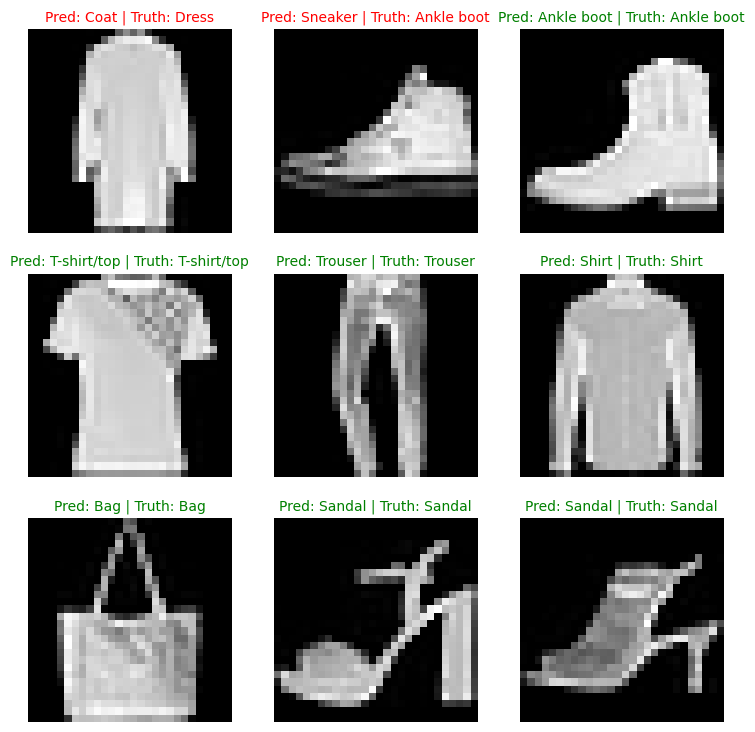

In [ ]:
# Plot predictions
plt.figure(figsize=(9, 9))
nrows = 3
ncols = 3
for i, sample in enumerate(test_samples):
  # Create a subplot
  plt.subplot(nrows, ncols, i+1)

  # Plot the target image
  plt.imshow(sample.squeeze(), cmap="gray")

  # Find the prediction label (in text form, e.g. "Sandal")
  pred_label = class_name[pred_classes[i]]

  # Get the truth label (in text form, e.g. "T-shirt")
  truth_label = class_name[test_labels[i]]

  # Create the title text of the plot
  title_text = f"Pred: {pred_label} | Truth: {truth_label}"

  # Check for equality and change title colour accordingly
  if pred_label == truth_label:
      plt.title(title_text, fontsize=10, c="g") # green text if correct
  else:
      plt.title(title_text, fontsize=10, c="r") # red text if wrong
  plt.axis(False);

 #Making a cinfusion Matrix  for further prediction evaluation

 It is way of evaluating a classification model vusually

In [ ]:
y_preds =[]
model_2.eval()
with torch.inference_mode():
  for X ,y in tqdm(test_data_loader, desc =" Making predictions..."):
    X, y = X.to(device) , y.to(device)
    y_logit = model_2(X)
    y_pred = torch.softmax(y_logit, dim=0).argmax(dim=1)

    y_preds.append(y_pred.cpu())

#print(y_preds)
y_pred_tensor = torch.cat(y_preds)
y_pred_tensor[:10]

 Making predictions...:   0%|          | 0/313 [00:00<?, ?it/s]

tensor([9, 2, 1, 1, 6, 1, 4, 6, 5, 7])

In [ ]:
len(y_pred_tensor )

10000

In [ ]:
try:
    import torchmetrics, mlxtend
except Exception as e:
    print("Fixing dependency versions...")
    !pip install -q numpy==1.26.4 torchmetrics mlxtend
    import os
    os.kill(os.getpid(), 9)


In [ ]:
# See if torchmetrics exists, if not, install it
try:
    import torchmetrics, mlxtend
    print(f"mlxtend version: {mlxtend.__version__}")

except:
    !pip install -q torchmetrics -U mlxtend # <- Note: If you're using Google Colab, this may require restarting the runtime
    import torchmetrics, mlxtend
    print(f"mlxtend version: {mlxtend.__version__}")

mlxtend version: 0.23.4


In [ ]:
import torchmetrics , mlxtend

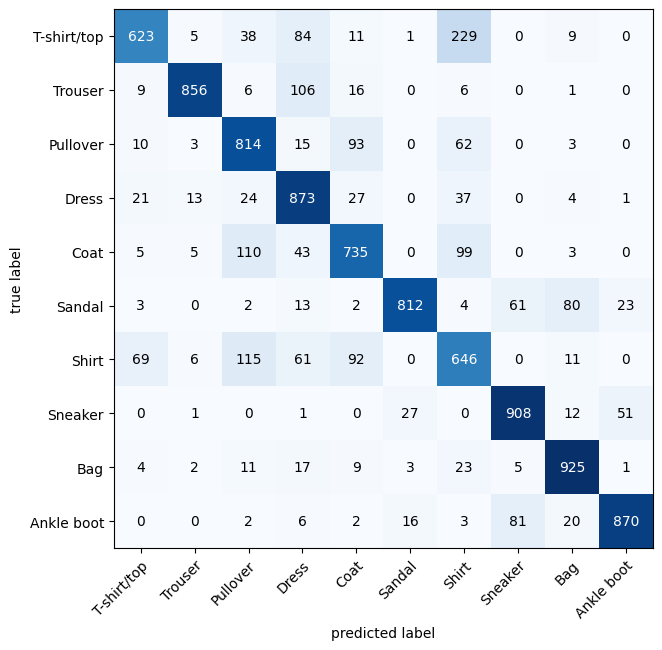

In [ ]:
from torchmetrics import ConfusionMatrix
from mlxtend.plotting import plot_confusion_matrix




confmat = ConfusionMatrix(task='multiclass', num_classes = len(class_name))
confmat_tensor = confmat(preds = y_pred_tensor , target =
                         test_data.targets)

fig , ax = plot_confusion_matrix(
    conf_mat = confmat_tensor.numpy(),
    class_names = class_name,
    figsize=(10 , 7)


)



In [ ]:
confmat_tensor

tensor([[623,   5,  38,  84,  11,   1, 229,   0,   9,   0],
        [  9, 856,   6, 106,  16,   0,   6,   0,   1,   0],
        [ 10,   3, 814,  15,  93,   0,  62,   0,   3,   0],
        [ 21,  13,  24, 873,  27,   0,  37,   0,   4,   1],
        [  5,   5, 110,  43, 735,   0,  99,   0,   3,   0],
        [  3,   0,   2,  13,   2, 812,   4,  61,  80,  23],
        [ 69,   6, 115,  61,  92,   0, 646,   0,  11,   0],
        [  0,   1,   0,   1,   0,  27,   0, 908,  12,  51],
        [  4,   2,  11,  17,   9,   3,  23,   5, 925,   1],
        [  0,   0,   2,   6,   2,  16,   3,  81,  20, 870]])

## save and load the best performing model

In [82]:
from pathlib import Path

MODEL_PATH = Path('models')
MODEL_PATH.mkdir(parents= True , exist_ok = True)

MODEL_NAME = "PyTorch_Computer_vision_model_2.pth"
MODEL_SAVE_PATH = MODEL_PATH / MODEL_NAME

print(f"Saving model to: {MODEL_SAVE_PATH}")
torch.save(obj = model_2.state_dict(),f=MODEL_SAVE_PATH)




Saving model to: models/PyTorch_Computer_vision_model_2.pth


## Create a new instance of the save model

In [83]:
loaded_model_2 = FashionMNISTModelV2(input_shape = 1 ,
                                     hidden_units = 10 ,
                                     output_shape = 10 )
loaded_model_2.load_state_dict(torch.load(f=MODEL_SAVE_PATH))
loaded_model_2 = loaded_model_2.to(device)

In [87]:
torch.manual_seed(42)
loaded_model_2_result = model_eval(
    model = loaded_model_2 ,
    data_loader = test_data_loader,
    loss_fn = loss_fn ,
    accuarcy_fn = accuarcy_fn,


)
loaded_model_2_result

{'Model_name': 'FashionMNISTModelV2',
 'Model_loss': 0.31404298543930054,
 'Model_Acc': 88.7679712460064}

In [88]:
model_2_result

{'Model_name': 'FashionMNISTModelV2',
 'Model_loss': 0.31404298543930054,
 'Model_Acc': 88.7679712460064}

In [89]:
loaded_model_2_result

{'Model_name': 'FashionMNISTModelV2',
 'Model_loss': 0.31404298543930054,
 'Model_Acc': 88.7679712460064}

In [91]:
torch.isclose(torch.tensor(model_2_result["Model_loss"]),
              torch.tensor(loaded_model_2_result["Model_loss"]),
              atol = 1e-08, # abosult tolerance
              rtol = 0.0001)# relative tolerance

tensor(True)